# Support Vector Machine (SVM) - Drug Response Classification

                 SUPPORT VECTOR MACHINE (SVM)

                    Machine Learning Algorithm
                             │
              ┌──────────────┴──────────────┐
              │                             │
      Classification                 Regression
           (SVC)                        (SVR)
           

                    DATASET
                       │
                       ▼
                Data Cleaning
                       │
                       ▼
              Missing Values
                       │
                       ▼
                  Encoding
                       │
                       ▼
              Train-Test Split
                       │
                       ▼
               StandardScaler
                       │
                       ▼
                Choose Kernel
     ┌──────────┬───────────┬───────────┐

     │          │           │

 Linear    --  Polynomial  ----    RBF

     │          │           │
     └──────────┴───────────┘

                 │
                 ▼
             Train SVM

                 │
                 ▼
            Make Predictions

                 │
                 ▼
        Accuracy & Evaluation
        
                 │
                 ▼
       Hyperparameter Tuning
       ├── C
       ├── Gamma
       └── Degree (Poly only)
                 │
                 ▼
            Best Model

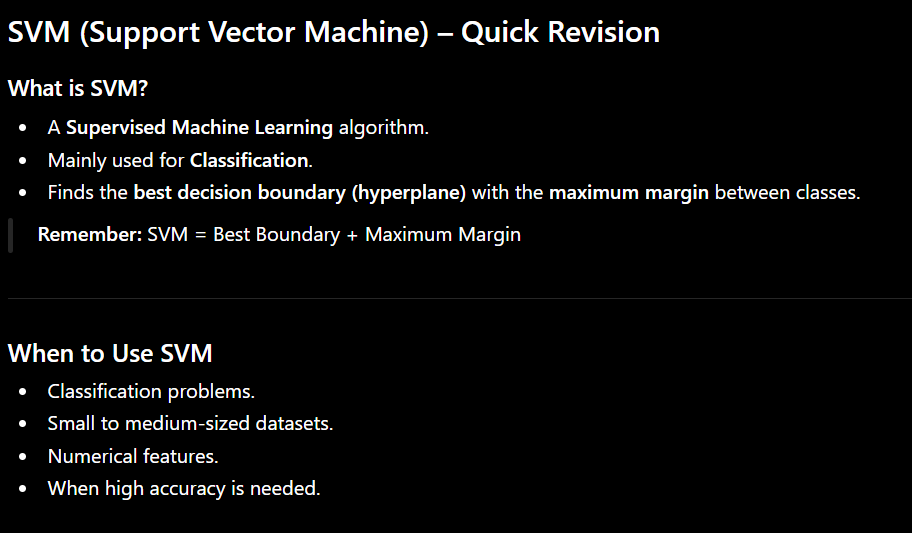

In [73]:
import pandas as pd
import numpy as np

In [74]:
df = pd.read_csv('/content/Pharma_Industry.csv')

In [75]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [76]:
df.shape

(500, 6)

In [77]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [78]:
df.info()
# as we can observe it already has values as numbers there is no need for the encoding and scaling

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [79]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


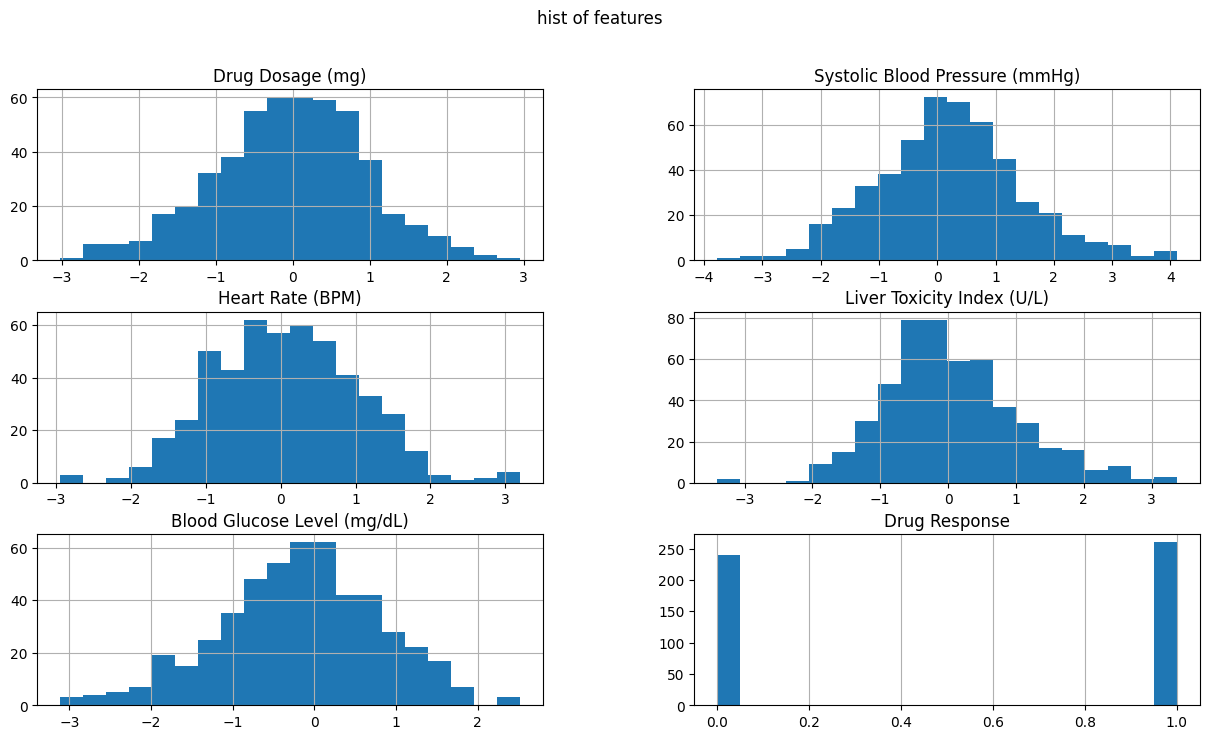

In [82]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,8),bins =20)
plt.suptitle('hist of features')
plt.grid(axis='y')
plt.show()




Most features appear approximately normally distributed.

 No severe skewness is observed.

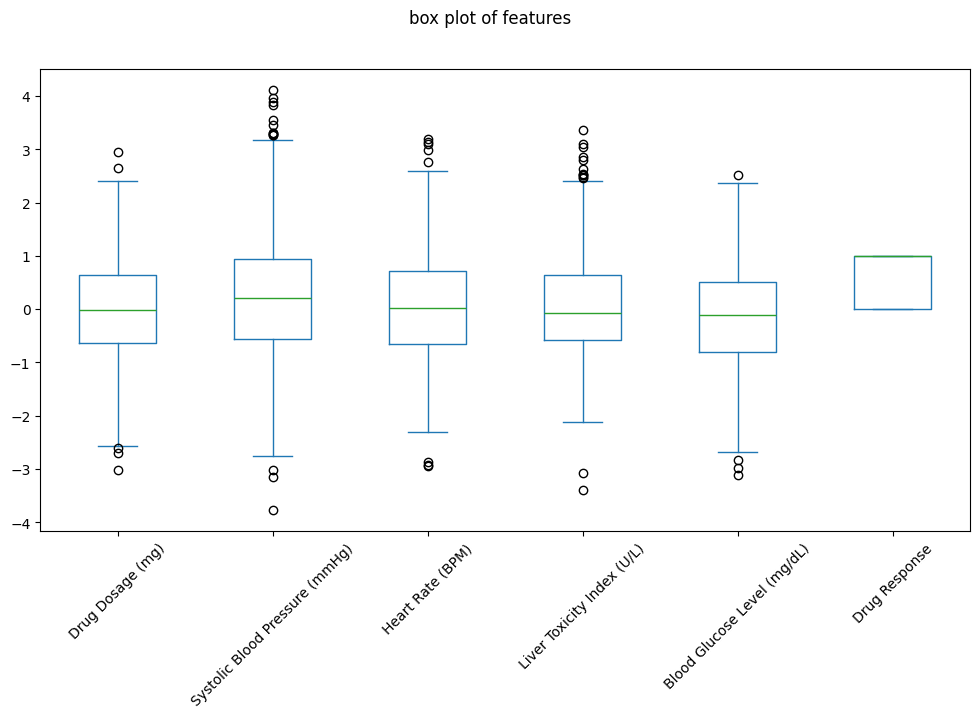

In [83]:
df.plot(
    kind='box',
    figsize=(12,6)
)
plt.xticks(rotation = 45)
plt.suptitle('box plot of features')
plt.show()

A few outliers are visible, but they are not extreme enough to require removal.

In [84]:
corelation = df.corr()
corelation

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.090618,0.040571,0.128127,0.012434,0.043457
Systolic Blood Pressure (mmHg),0.090618,1.000000,-0.039195,0.283672,0.037228,0.305226
Heart Rate (BPM),0.040571,-0.039195,1.000000,0.005818,0.049897,-0.009715
Liver Toxicity Index (U/L),0.128127,0.283672,0.005818,1.000000,0.229474,0.434722
Blood Glucose Level (mg/dL),0.012434,0.037228,0.049897,0.229474,1.000000,0.169342
Drug Response,0.043457,0.305226,-0.009715,0.434722,0.169342,1.000000


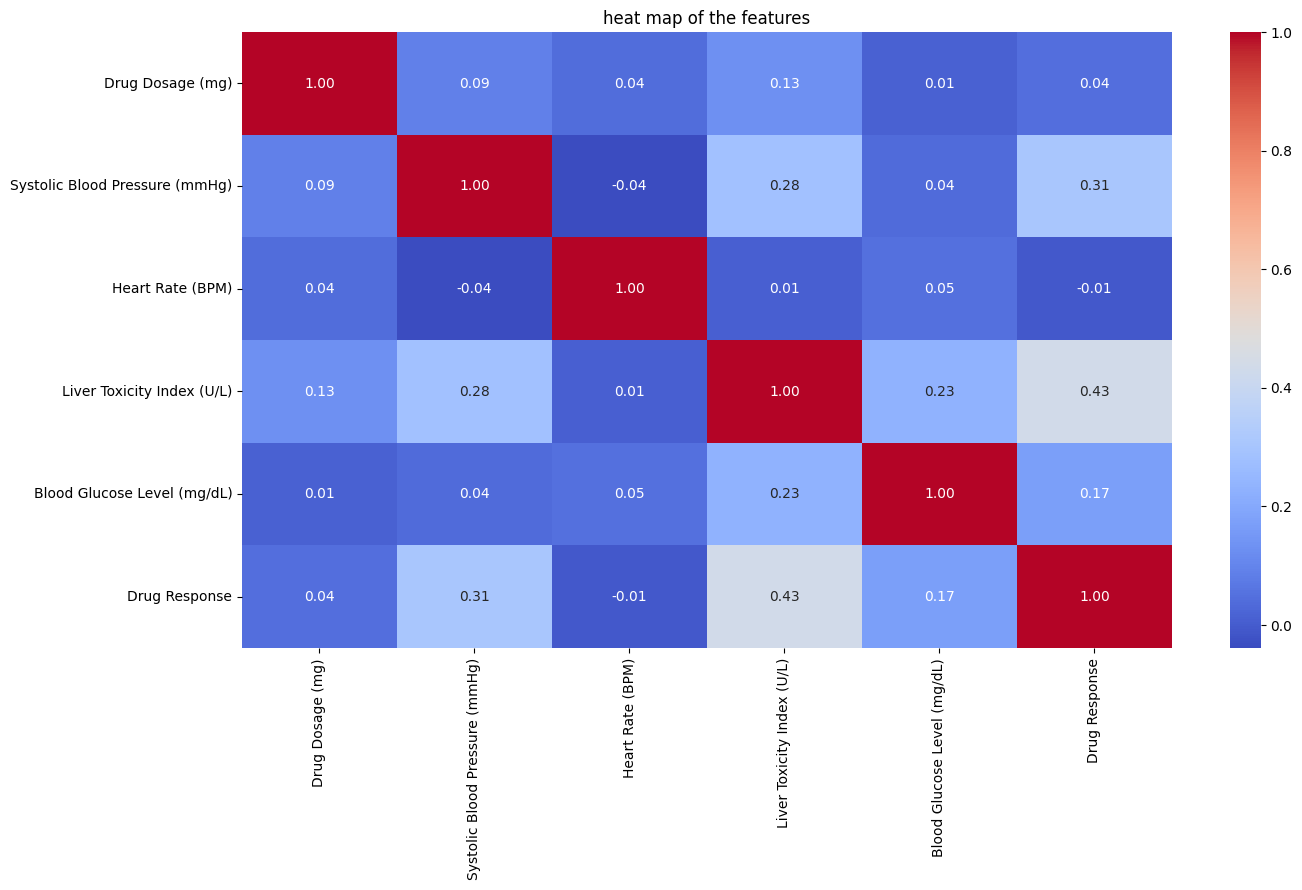

In [85]:
import seaborn as sns
plt.figure(figsize=(15,8))
sns.heatmap(
    data = corelation,
    annot= True,
    cmap = 'coolwarm',
    fmt = '.2f'

)
plt.title('heat map of the features')
plt.show()

The features show weak to moderate correlations, indicating limited multicollinearity.

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

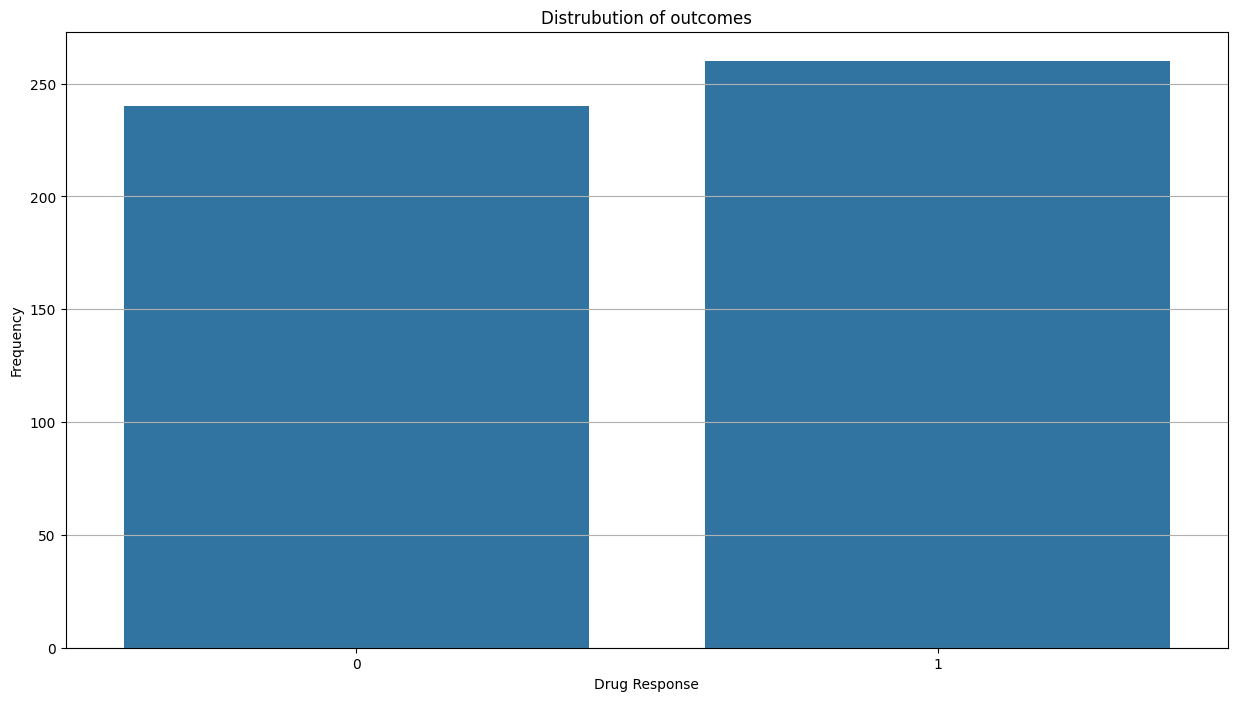

In [87]:
plt.figure(figsize=(15,8))
sns.countplot(
    data = df,
    x = 'Drug Response'
)
plt.title('Distrubution of outcomes')
plt.xlabel('Drug Response')
plt.ylabel('Frequency')

plt.grid(axis ='y')
plt.show()

The target classes are nearly balanced (260 vs 240), making the dataset suitable for classification

## Kernel Comparison

In [88]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Drug Response', axis=1)  # Split the data
y = df['Drug Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler() # Scale the training and testing data
# see the differnce between the steps x_train_scaled and x_test_scaled
# we can directly do it in one step like X_scaled = scaler.fit_transform(X) to prevent the data leakage we did this
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SVM is a distance-based algorithm.

Features with larger scales can dominate the decision boundary.

Therefore, StandardScaler is applied so that all features contribute equally.

In [89]:
from sklearn.svm import SVC # Import the SVM model

In [109]:
# Create the SVM model
# RBF Kernel
svm_model = SVC(
    kernel='rbf',
    random_state = 42
)

**Kernels**

A kernel helps SVM separate data.

**Linear**

-->Straight-line separation.

-->Fast.

-->Use when data is nearly linear.

-->kernel='linear'

**Polynomial**

-->Curved decision boundary.

-->Use for moderately complex data.

-->kernel='poly'

**RBF (Most Common)**

-->Handles nonlinear data.

-->Default choice when unsure.

-->kernel='rbf'

Remember: If you don't know which kernel to choose → RBF

In [91]:
svm_model.fit(X_train_scaled,y_train)

SVC(random_state=42)

In [92]:
y_pred = svm_model.predict(X_test_scaled)

In [93]:
y_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1])

In [94]:
from sklearn.metrics import accuracy_score , confusion_matrix

In [95]:
rbf_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy in percentage : ", rbf_accuracy*100)

Accuracy in percentage :  84.0


In [96]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[37  7]
 [ 9 47]]


In [97]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        44
           1       0.87      0.84      0.85        56

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



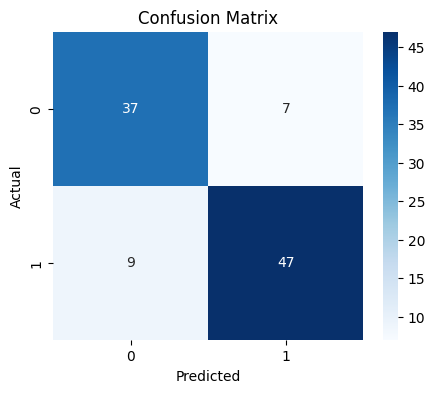

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [110]:
# Linear Kernel
linear_svm = SVC(
    kernel='linear',
    random_state=42
    )

linear_svm.fit(X_train_scaled, y_train)

linear_pred = linear_svm.predict(X_test_scaled)

linear_accuracy = accuracy_score(y_test, linear_pred)

print("Linear Accuracy:", linear_accuracy)

Linear Accuracy: 0.78


In [111]:
# Polynomial Kernel
poly_svm = SVC(
    kernel='poly',
    random_state=42
    )

poly_svm.fit(X_train_scaled, y_train)

poly_pred = poly_svm.predict(X_test_scaled)

poly_accuracy = accuracy_score(y_test, poly_pred)

print("Polynomial Accuracy:", poly_accuracy)


Polynomial Accuracy: 0.71


In [101]:
kernel_results = pd.DataFrame({
    "Kernel": ["Linear", "Polynomial", "RBF"],
    "Accuracy": [linear_accuracy, poly_accuracy, rbf_accuracy]
})

kernel_results

,Kernel,Accuracy
0,Linear,0.78
1,Polynomial,0.71
2,RBF,0.84


The RBF kernel achieved the highest accuracy because it can model nonlinear relationships between the features, whereas the Linear kernel is suitable only for linearly separable data

## Hyperparameter Tuning - C

**Hyperparameters**

They control how the model learns.

**C**

Controls how strict the model is.

--> Small C → Simpler model, allows some mistakes.

--> Large C → Complex model, tries to classify everything correctly.

Remember: C = Strictness

**Gamma**

Controls how much influence each data point has.

-->Small Gamma → Smooth boundary.

-->Large Gamma → Complex boundary.

Remember: Gamma = Boundary Shape

**Degree**

Used only with Polynomial Kernel.

--> Higher Degree → More complex curve.

Remember: Degree = Curve Complexity

In [102]:
svm_c01 = SVC(kernel='rbf', C=0.1, random_state=42)

svm_c01.fit(X_train_scaled, y_train)

pred_c01 = svm_c01.predict(X_test_scaled)

acc_c01 = accuracy_score(y_test, pred_c01)

print("Accuracy (C=0.1):", acc_c01)

Accuracy (C=0.1): 0.8


In [103]:
svm_c1 = SVC(kernel='rbf', C=1, random_state=42)

svm_c1.fit(X_train_scaled, y_train)

pred_c1 = svm_c1.predict(X_test_scaled)

acc_c1 = accuracy_score(y_test, pred_c1)

print("Accuracy (C=1):", acc_c1)

Accuracy (C=1): 0.84


In [104]:
svm_c10 = SVC(kernel='rbf', C=10, random_state=42)

svm_c10.fit(X_train_scaled, y_train)

pred_c10 = svm_c10.predict(X_test_scaled)

acc_c10 = accuracy_score(y_test, pred_c10)

print("Accuracy (C=10):", acc_c10)

Accuracy (C=10): 0.78


In [105]:
c_results = pd.DataFrame({
    "C Value": [0.1, 1, 10],
    "Accuracy": [acc_c01, acc_c1, acc_c10]
})

c_results

,C Value,Accuracy
0,0.1,0.80
1,1.0,0.84
2,10.0,0.78


Increasing the value of C reduced training errors but may increase the risk of overfitting. In this dataset, C = __ provided the best balance between accuracy and generalization.

## Hyperparameter Tuning - Gamma

In [106]:
svm_scale = SVC(kernel='rbf', gamma='scale', random_state=42)

svm_scale.fit(X_train_scaled, y_train)

pred_scale = svm_scale.predict(X_test_scaled)

acc_scale = accuracy_score(y_test, pred_scale)

print("Accuracy (gamma=scale):", acc_scale)

Accuracy (gamma=scale): 0.84


In [107]:
svm_auto = SVC(kernel='rbf', gamma='auto', random_state=42)

svm_auto.fit(X_train_scaled, y_train)

pred_auto = svm_auto.predict(X_test_scaled)

acc_auto = accuracy_score(y_test, pred_auto)

print("Accuracy (gamma=auto):", acc_auto)

Accuracy (gamma=auto): 0.84


In [108]:
gamma_results = pd.DataFrame({
    "Gamma": ["scale", "auto"],
    "Accuracy": [acc_scale, acc_auto]
})

gamma_results

,Gamma,Accuracy
0,scale,0.84
1,auto,0.84


The 'scale' gamma setting produced better performance because it automatically adjusts the influence of training samples based on the data variance.

## conclusion :

In this project, a Support Vector Machine (SVM) classifier was developed to predict drug response based on patient health indicators.

The dataset was first explored using EDA, then preprocessed by splitting into training and testing sets and applying feature scaling using StandardScaler.

The SVM model achieved good classification performance. Different kernels and hyperparameters (C and Gamma) were compared, and the best-performing configuration was identified.

This project demonstrates that Support Vector Machines are effective for binary classification problems such as drug response prediction.

**Strengths **

-->Effective for classification problems.

-->Works well with high-dimensional data.

-->Performs well on small and medium-sized datasets.

**Weaknesses**

-->Sensitive to parameter tuning.


-->Requires feature scaling.

-->Slower on very large dataset

| Topic             | Remember                                                                                                       |
| ----------------- | -------------------------------------------------------------------------------------------------------------- |
| SVM               | Finds the best boundary with the maximum margin between classes.                                               |
| Why use SVM?      | High accuracy, handles linear and nonlinear classification.                                                    |
| Prerequisite      | Clean data, encode categorical variables, split data, and **scale features**.                                  |
| Linear Kernel     | Use when data is approximately linearly separable.                                                             |
| Polynomial Kernel | Use when the boundary needs moderate curves.                                                                   |
| RBF Kernel        | Default choice when the relationship is nonlinear or unknown.                                                  |
| C                 | Controls the trade-off between allowing training errors and fitting the data closely.                          |
| Gamma             | Controls how much influence each training point has; small = smoother boundary, large = more complex boundary. |
| Degree            | Used only with the polynomial kernel to control curve complexity.                                              |


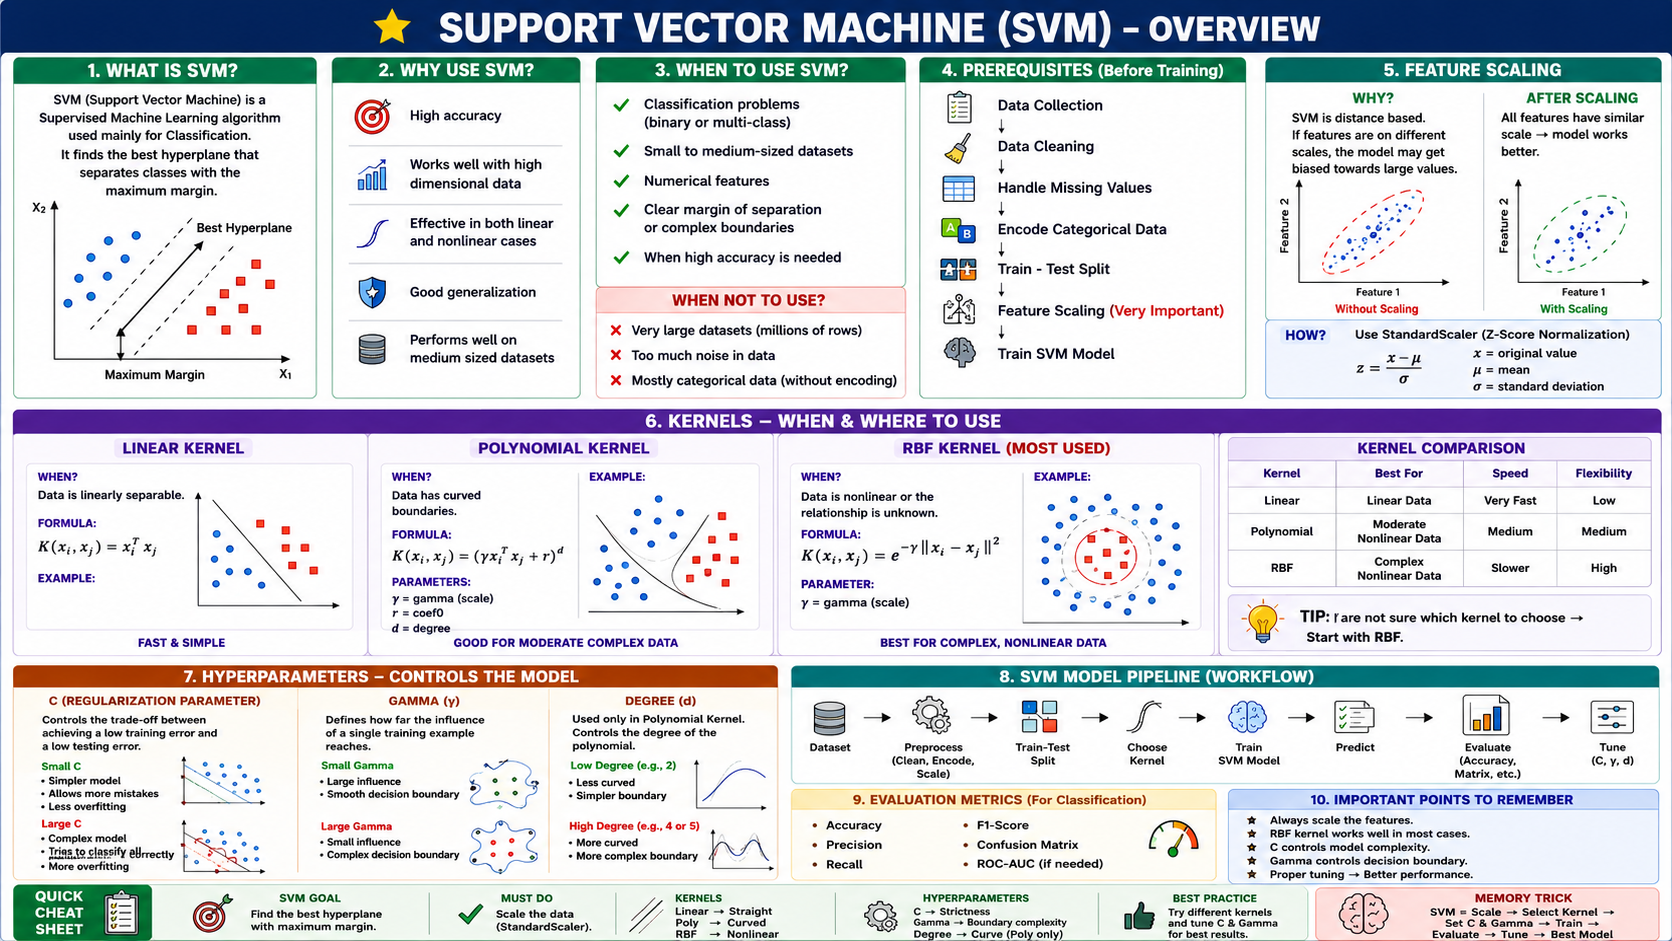